In [0]:
import numpy as np
import tensorflow as tf

In [3]:
!ls

sample_data


In [1]:
!nvidia-smi

Tue Oct 16 06:38:00 2018       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 396.44                 Driver Version: 396.44                    |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:00:04.0 Off |                    0 |
| N/A   31C    P8    27W / 149W |      0MiB / 11441MiB |      0%      Default |
+-------------------------------+----------------------+----------------------+
                                                                               
+-----------------------------------------------------------------------------+
| Processes:                                                       GPU Memory |
|  GPU  

In [4]:
from keras.datasets import cifar10
from functools import reduce

Using TensorFlow backend.


In [5]:
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

170500096/170498071 [==============================] - 74s 0us/step


In [6]:
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)
print(X_train.dtype)
print(np.max(X_train), np.min(X_train))

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)
uint8
255 0


In [7]:
X_train = X_train.astype('float32') / 255.
print(X_train.dtype)
print(np.max(X_train), np.min(X_train))

X_test = X_test.astype('float32') / 255.
print(X_test.dtype)
print(np.max(X_test), np.min(X_test))

Y_train = np.squeeze(Y_train)
Y_test = np.squeeze(Y_test)

float32
1.0 0.0
float32
1.0 0.0


In [8]:
print(Y_train.shape)

(50000,)


In [0]:
label_dict = {
    0: 'airplane',
    1: 'automobile',
    2: 'frog',
    3: 'cat',
    4: 'deer',
    5: 'dog',
    6: 'frog',
    7: 'horse',
    8: 'ship',
    9: 'truck',    
}

In [0]:
sess_config = tf.ConfigProto(gpu_options=tf.GPUOptions(allow_growth=True))
sess = tf.Session(config=sess_config)

# Describe
dataset = tf.data.Dataset.from_tensor_slices( (X_train, Y_train))
dataset = dataset.batch(128).shuffle( 128*10 ).repeat()
dataset_generator = dataset.make_one_shot_iterator().get_next()

# Execute
batch_X, batch_Y = sess.run( dataset_generator)

In [13]:
print( batch_X.shape )
print (batch_Y.shape)

(128, 32, 32, 3)
(128,)


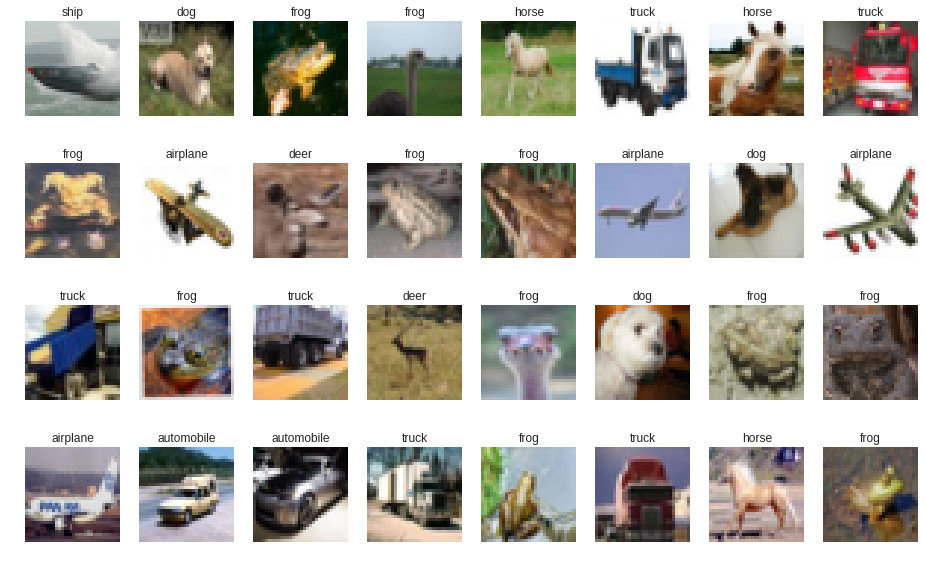

In [14]:
# 샘플 출력 및 시각화
%matplotlib inline
import matplotlib.pyplot as plt

plot_idx = np.random.randint(0, len(X_train), 32)

plot_images = X_train[plot_idx]
plot_labels = Y_train[plot_idx]

fig = plt.figure(figsize=(16, 10))
for i, (img, label) in enumerate(zip(plot_images, plot_labels)):
  
    a = fig.add_subplot(4, 8, i+1)
    a.axis("off")
    a.set_title(label_dict[label])
    plt.imshow(img)

In [0]:

import tensorflow.contrib.layers as layers
he_init = layers.variance_scaling_initializer()

learning_rate = 0.0001

# None은 배치사이즈이다.
inputs = tf.placeholder(tf.float32, [None, 32, 32, 3])
label  = tf.placeholder(tf.int64, [None])
is_training = tf.placeholder(tf.bool)

# TF의 가장 하위 기능을 이용해서 구현을 하려는 코드임
# 요즘엔 tf.layers를 이용해서 짠다.


def conv(inputs, num_filter, ksize, stride, padding, is_training, scope=None):
    bottom_shape = inputs.get_shape().as_list()[3]
    # 입력 채널 수 = bottom_shape
    # 출력 채널 수 = num_filter
    with tf.variable_scope(scope):
        W = tf.get_variable("W", [ksize, ksize, bottom_shape, num_filter],
                            initializer=he_init)
        
        x = tf.nn.conv2d(inputs, W, strides=[1, stride, stride, 1],
                         padding=padding)
        x = layers.batch_norm(x, is_training=is_training,
                              decay=0.9, updates_collections=None)
        x = tf.nn.relu(x)
        
    return x

def maxpool(inputs, ksize, stride, padding, scope=None):
    with tf.variable_scope(scope):
        pool = tf.nn.max_pool(inputs, ksize=[1, ksize, ksize, 1],
                              strides=[1, stride, stride, 1],
                              padding=padding)
    return pool
    
def fc(inputs, num_dims, scope=None):
    bottom_shape = inputs.get_shape().as_list()
    if len(bottom_shape) > 2:
        inputs = tf.reshape(inputs,
                            [-1, reduce(lambda x, y: x*y, bottom_shape[1:])])
        bottom_shape = inputs.get_shape().as_list()
        
    with tf.variable_scope(scope):
        W = tf.get_variable("W", [bottom_shape[1], num_dims],
                            initializer=he_init)
        b = tf.get_variable("b", [num_dims],
                            initializer=tf.constant_initializer(0))
        
        out = tf.matmul(inputs, W) + b
    return out
        
def fc_relu(inputs, num_dims, is_training, scope=None):
    with tf.variable_scope(scope):
        out = fc(inputs, num_dims, scope="fc")
        bn  = layers.batch_norm(out, is_training=is_training,
                                decay=0.9, updates_collections=None)
        relu = tf.nn.relu(bn)
    return relu


In [0]:

conv1 = conv(inputs, 32, ksize=3, stride=1, 
             padding="SAME", is_training=is_training, scope="conv1")
conv1 = maxpool(conv1, ksize=2, stride=2, 
                padding="SAME", scope="pool1")

conv2 = conv(conv1, 32, ksize=3, stride=1, 
             padding="SAME", is_training=is_training, scope="conv2")
conv2 = maxpool(conv2, ksize=2, stride=2, 
                padding="SAME", scope="pool2")

conv3 = conv(conv2, 32, ksize=3, stride=1, 
             padding="SAME", is_training=is_training, scope="conv3")
conv3 = maxpool(conv3, ksize=2, stride=2, 
                padding="SAME", scope="pool3")

fc1   = fc_relu(conv3, 128, is_training=is_training, scope="fc1")
logit = fc(fc1, 10, scope="logit")


'\nconv1 = conv(inputs, 32, ksize=3, stride=1, \n             padding="SAME", is_training=is_training, scope="conv1")\nconv1 = maxpool(conv1, ksize=2, stride=2, \n                padding="SAME", scope="pool1")\n\nconv2 = conv(conv1, 32, ksize=3, stride=1, \n             padding="SAME", is_training=is_training, scope="conv2")\nconv2 = maxpool(conv2, ksize=2, stride=2, \n                padding="SAME", scope="pool2")\n\nconv3 = conv(conv2, 32, ksize=3, stride=1, \n             padding="SAME", is_training=is_training, scope="conv3")\nconv3 = maxpool(conv3, ksize=2, stride=2, \n                padding="SAME", scope="pool3")\n\nfc1   = fc_relu(conv3, 128, is_training=is_training, scope="fc1")\nlogit = fc(fc1, 10, scope="logit")\n'

In [0]:
learning_rate = 0.0001

inputs = tf.placeholder(tf.float32, [None, 32, 32, 3])
label  = tf.placeholder(tf.int64, [None])
is_training = tf.placeholder(tf.bool)

(?, 32, 32, 64)


In [18]:
conv1 = tf.layers.conv2d(inputs, filters=64, kernel_size=3, strides=1,
                         padding='same', activation=tf.nn.relu)
print(conv1.shape)
pool1 = tf.layers.max_pooling2d(conv1, 2, 2)
print(pool1.shape)
conv2 = tf.layers.conv2d(pool1, filters=32, kernel_size=3, strides=1,
                         padding='same', activation=tf.nn.relu)
print(conv2.shape)
pool2 = tf.layers.max_pooling2d(conv2, 2, 2)
print(pool2.shape)
conv3 = tf.layers.conv2d(pool2, filters=16, kernel_size=3, strides=1,
                         padding='same', activation=tf.nn.relu)
print(conv3.shape)
pool3 = tf.layers.max_pooling2d(conv3, 2, 2)
print(pool3.shape)
dense1 = tf.layers.dense(tf.layers.flatten(pool3), 1024, activation=tf.nn.relu)
print(dense1.shape)
dense1_dropout = tf.layers.dropout(dense1, rate=0.4, training=is_training)
print(dense1_dropout.shape)
dense2 = tf.layers.dense(dense1_dropout, 128, activation=tf.nn.relu)
print(dense2.shape)
dense2_dropout = tf.layers.dropout(dense2, rate=0.4, training=is_training)
print(dense2_dropout.shape)
logit = tf.layers.dense(dense2_dropout, 10)
print(logit.shape)

(?, 32, 32, 64)
(?, 16, 16, 64)
(?, 16, 16, 32)
(?, 8, 8, 32)
(?, 8, 8, 16)
(?, 4, 4, 16)
(?, 1024)
(?, 1024)
(?, 128)
(?, 128)
(?, 10)


In [0]:
# 테스트 시 사용하는 연산 그래프 정의
pred_op = tf.nn.softmax(logit)
correct = tf.equal(label, tf.argmax(pred_op, 1))
accuracy = tf.reduce_mean(tf.cast(correct, tf.float32))

loss_op = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=label, logits=logit))
opt = tf.train.AdamOptimizer(learning_rate).minimize(loss_op)

In [0]:
sess_config = tf.ConfigProto(gpu_options=tf.GPUOptions(allow_growth=True))
sess = tf.Session(config=sess_config)
sess.run(tf.global_variables_initializer())

In [0]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
dataset = dataset.batch(128).shuffle(128*10).repeat()
dataset_generator = dataset.make_one_shot_iterator().get_next()
batch_X, batch_Y = sess.run(dataset_generator)

In [22]:
print(batch_X.shape, batch_Y.shape)
print(np.max(batch_X), np.min(batch_X))

(128, 32, 32, 3) (128,)
1.0 0.0


In [23]:
for step in range(5000):
    batch_X, batch_Y = sess.run(dataset_generator)
    _, loss = sess.run([opt, loss_op], feed_dict={inputs: batch_X, label:batch_Y, is_training: True})
    
    if (step+1) % 500 == 0:
        print(step+1, loss)
    
acc_test = sess.run(accuracy,
    feed_dict={inputs:X_test, label:np.squeeze(Y_test), is_training: False})
print("step", step+1, "test_accuracy:", acc_test)

500 1.6656208
1000 1.6911638
1500 1.4780618
2000 1.5848038
2500 1.2345209
3000 1.3096182
3500 1.2871716
4000 1.1527393
4500 1.1952147
5000 0.9350501
step 5000 test_accuracy: 0.6084


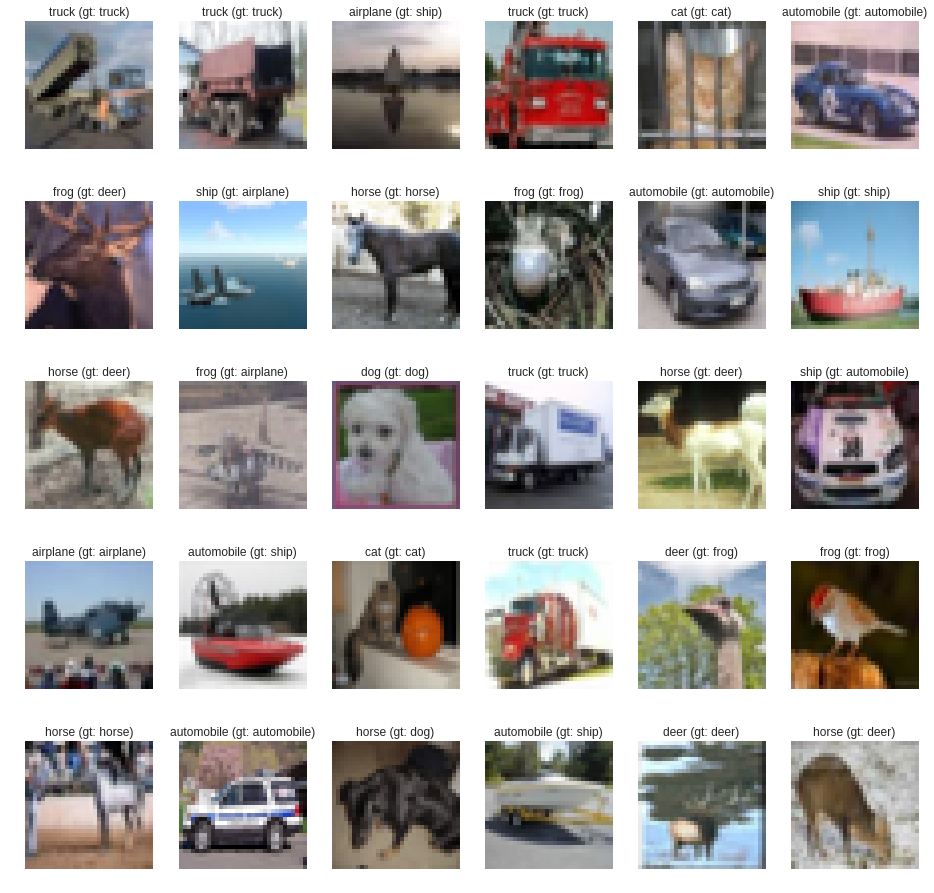

In [24]:
# 테스트 샘플 출력 및 시각화
%matplotlib inline
import matplotlib.pyplot as plt

plot_idx = np.random.randint(0, len(X_test), 30)

plot_images = X_test[plot_idx]
plot_labels = Y_test[plot_idx]

plot_preds = sess.run(pred_op, feed_dict={inputs:plot_images, is_training:False})
plot_preds = np.argmax(plot_preds, axis=1)

fig = plt.figure(figsize=(16, 16))
for i, (img, label, pred) in enumerate(zip(plot_images, plot_labels, plot_preds)):
    a = fig.add_subplot(5, 6, i+1)
    a.set_title("{} (gt: {})".format(label_dict[pred], label_dict[label]))
    a.axis("off")
    plt.imshow(img)
